# C++-accelerated traversal benchmarks

This notebook builds a C++ extension (pybind11) that implements graph generation
and traversal algorithms. Python is only used to trigger runs and plot results.

Run the cells top to bottom:
1) Build the C++ module
2) Configure experiments
3) Execute benchmarks (C++)
4) Plot results (Python)

In [1]:
from pathlib import Path
import os
import subprocess
import sys

def resolve_cpp_dir():
    cwd = Path.cwd()
    # If we're already in labs/lab3, prefer ./cpp
    if (cwd / "cpp").exists():
        return cwd / "cpp"
    return cwd / "labs" / "lab3" / "cpp"

def find_windows_sdk_version():
    sdk_root = Path("C:/Program Files (x86)/Windows Kits/10/Include")
    if not sdk_root.exists():
        return None
    versions = sorted([p for p in sdk_root.iterdir() if p.is_dir()], reverse=True)
    for v in versions:
        if (v / "ucrt" / "io.h").exists():
            return v.name
    return None

CPP_DIR = resolve_cpp_dir()
CPP_DIR.mkdir(parents=True, exist_ok=True)

subprocess.run([sys.executable, "-m", "pip", "install", "pybind11"], check=True)

env = os.environ.copy()
sdk_version = find_windows_sdk_version()
if sdk_version:
    sdk_inc = f"C:/Program Files (x86)/Windows Kits/10/Include/{sdk_version}"
    sdk_lib = f"C:/Program Files (x86)/Windows Kits/10/Lib/{sdk_version}"
    include_paths = [
        f"{sdk_inc}/ucrt",
        f"{sdk_inc}/shared",
        f"{sdk_inc}/um",
        f"{sdk_inc}/winrt",
    ]
    lib_paths = [
        f"{sdk_lib}/ucrt/x64",
        f"{sdk_lib}/um/x64",
    ]
    env["INCLUDE"] = ";".join(include_paths + [env.get("INCLUDE", "")])
    env["LIB"] = ";".join(lib_paths + [env.get("LIB", "")])
else:
    raise RuntimeError("Windows SDK not found. Install Windows 10/11 SDK in Visual Studio Build Tools.")

proc = subprocess.run(
    [sys.executable, "setup.py", "build_ext", "--inplace"],
    cwd=CPP_DIR,
    text=True,
    capture_output=True,
    env=env,
    )
print(proc.stdout)
print(proc.stderr)
proc.check_returncode()

running build_ext
building 'graph_algos_cpp' extension
creating build
creating build\temp.win-amd64-cpython-311
creating build\temp.win-amd64-cpython-311\Release
"C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Tools\MSVC\14.44.35207\bin\HostX86\x64\cl.exe" /c /nologo /O2 /W3 /GL /DNDEBUG /MD -IC:\Users\Nikita\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pybind11\include "-IC:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\include" "-IC:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Include" "-IC:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Tools\MSVC\14.44.35207\include" "-IC:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\VS\include" "-IC:\Program Files (x86)\Windows Kits\10\include\10.0.22621.0\ucrt" "-IC:\Program Files (x86)\Windows Kits\10\\include

In [3]:
from pathlib import Path
import sys

def resolve_cpp_dir():
    cwd = Path.cwd()
    if (cwd / "cpp").exists():
        return cwd / "cpp"
    return cwd / "labs" / "lab3" / "cpp"

CPP_DIR = resolve_cpp_dir()
if str(CPP_DIR) not in sys.path:
    sys.path.insert(0, str(CPP_DIR))

import graph_algos_cpp as gac

RANDOM_SEED = 42
VERTEX_SIZES = [100, 200, 500, 1000, 2000]
NUM_TRIALS = 3
DENSITIES = ["sparse", "dense"]

GRAPH_TYPES = [
    "Simple graph",
    "Multigraph",
    "Pseudograph",
    "Directed graph",
    "Directed Multigraph",
    "Complete graph",
    "Wheels",
    "Bipartite graph",
    "Regular graph",
    "Planar graph (grid-based)",
    "Trees",
    "Cyclic graph",
    "Weighted graph",
]

## Traversal visualizations (small graphs)

Each graph type below is drawn with 10-15 nodes, and each of the four traversal variants is visualized.
The "optimized" versions use a different neighbor ordering to make the traversal order visually distinct.

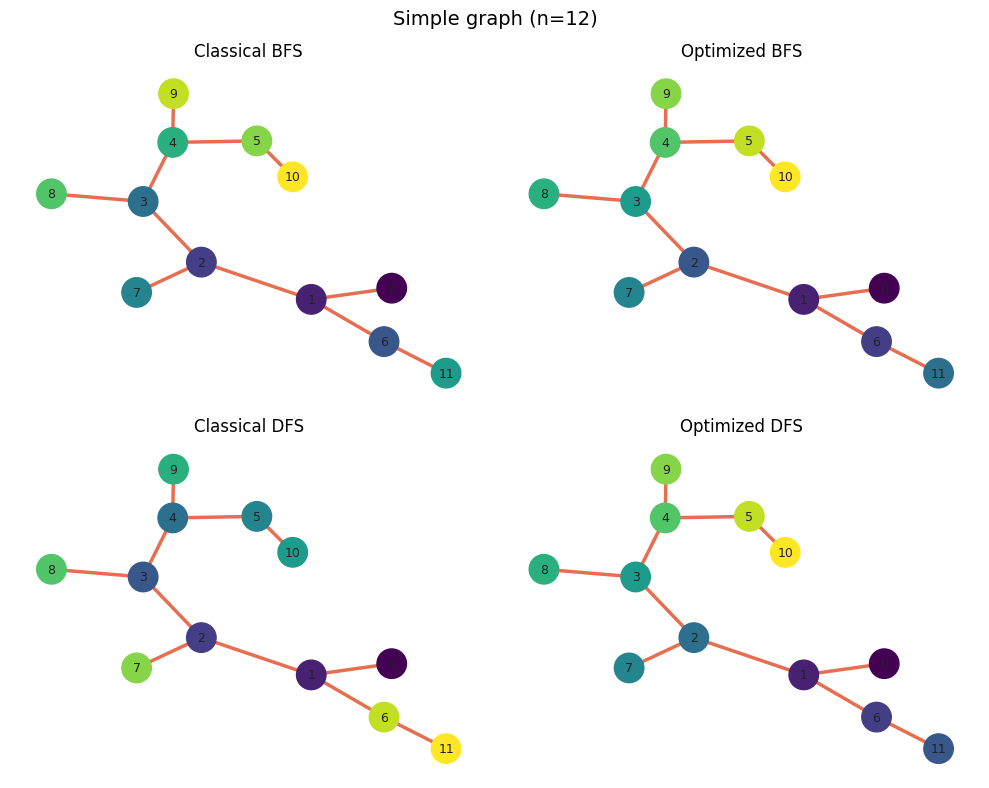

C:\Users\Nikita\AppData\Local\Temp\ipykernel_20752\1822569331.py:85: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


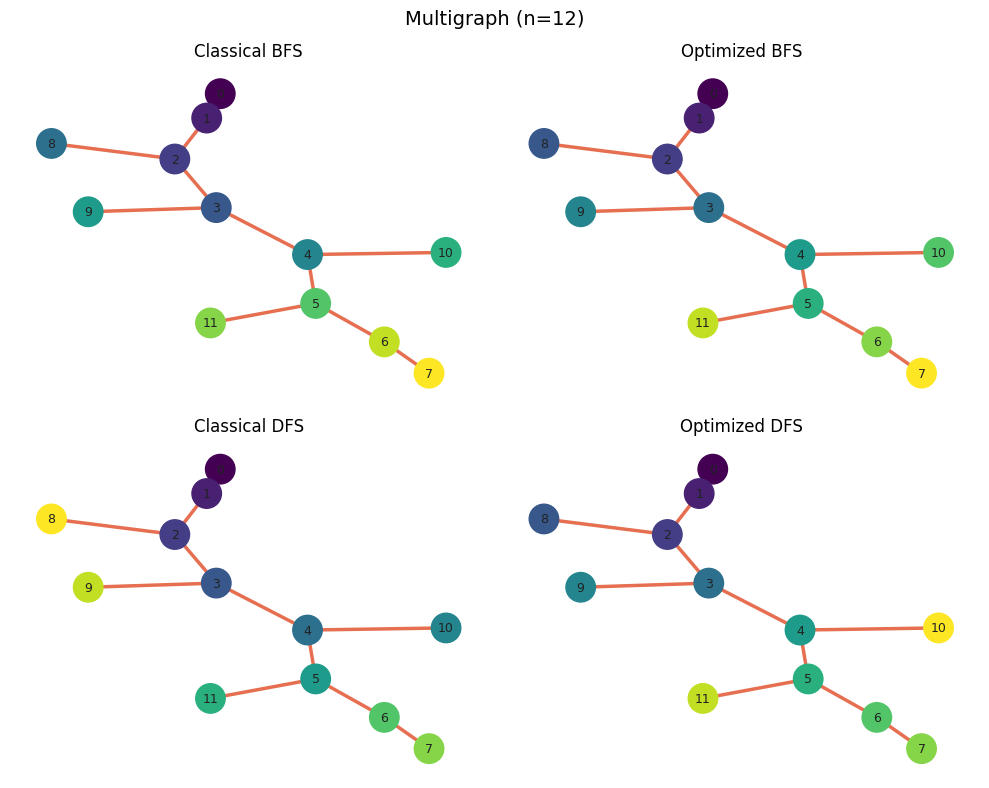

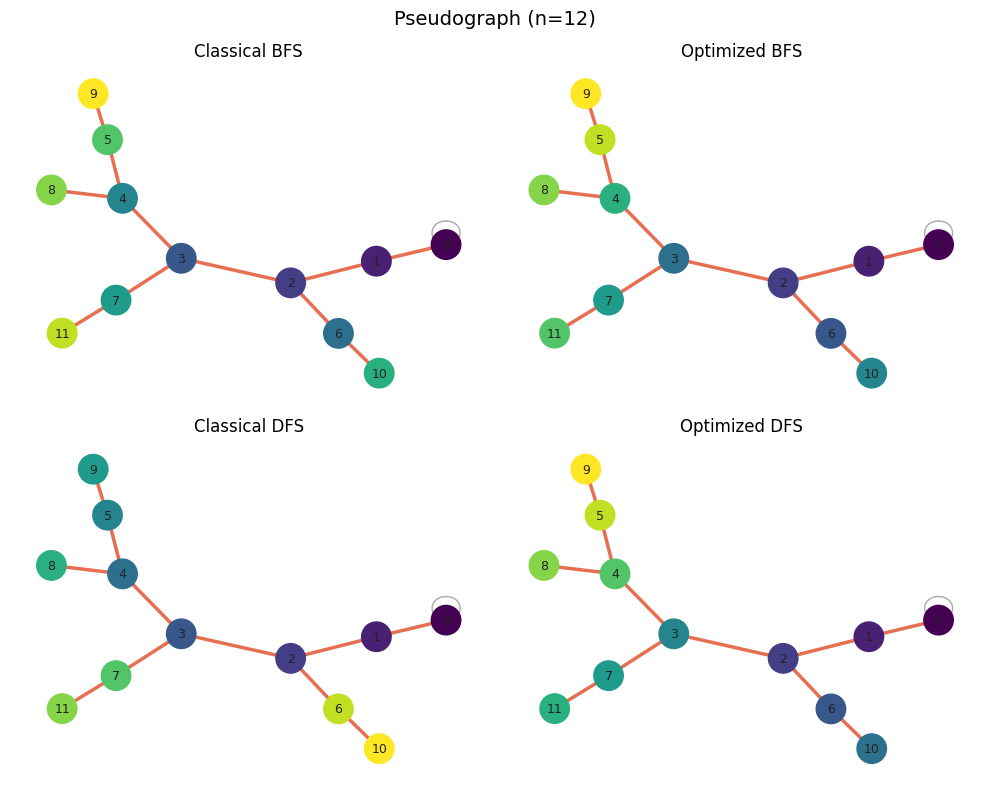

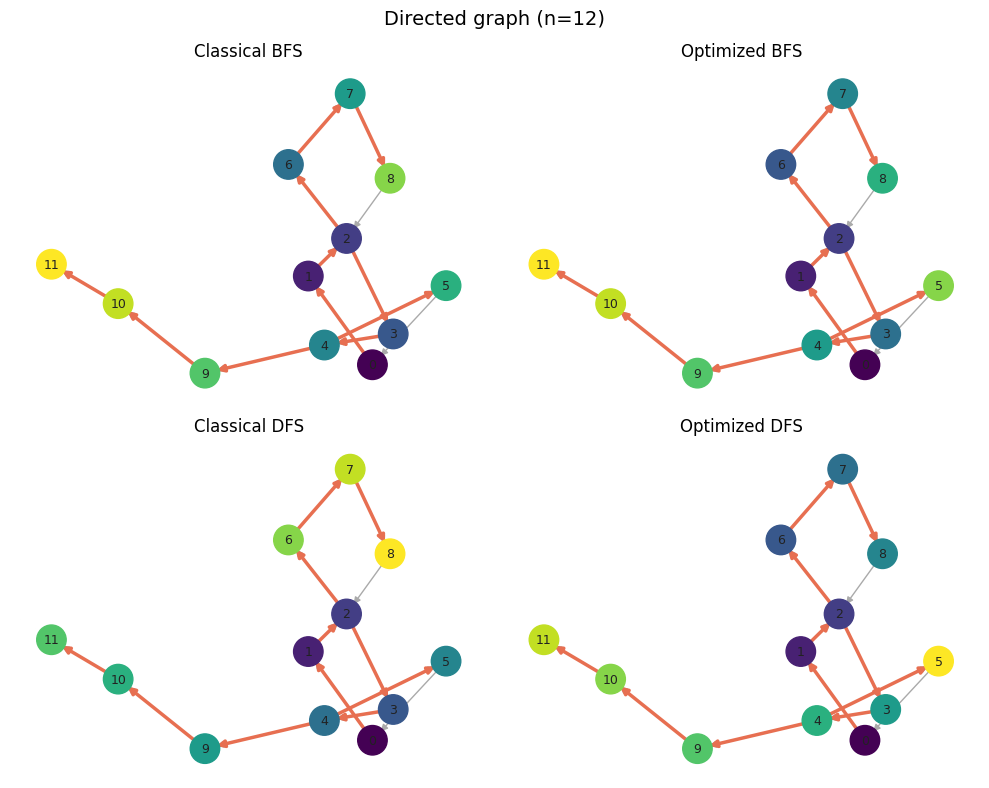

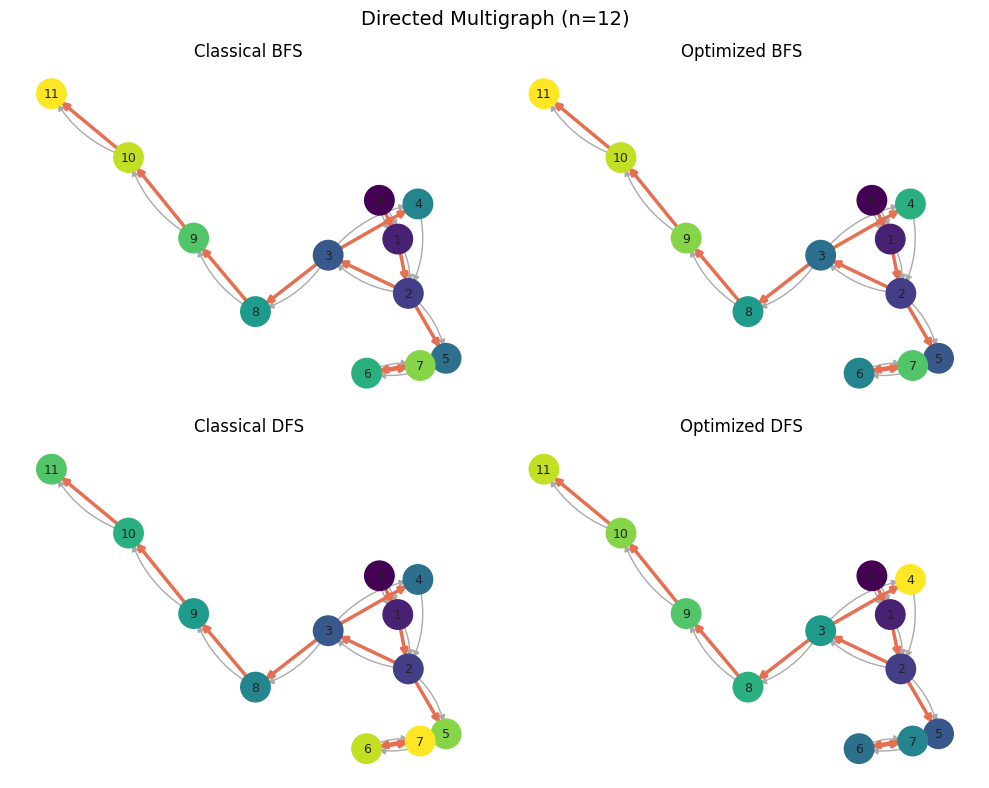

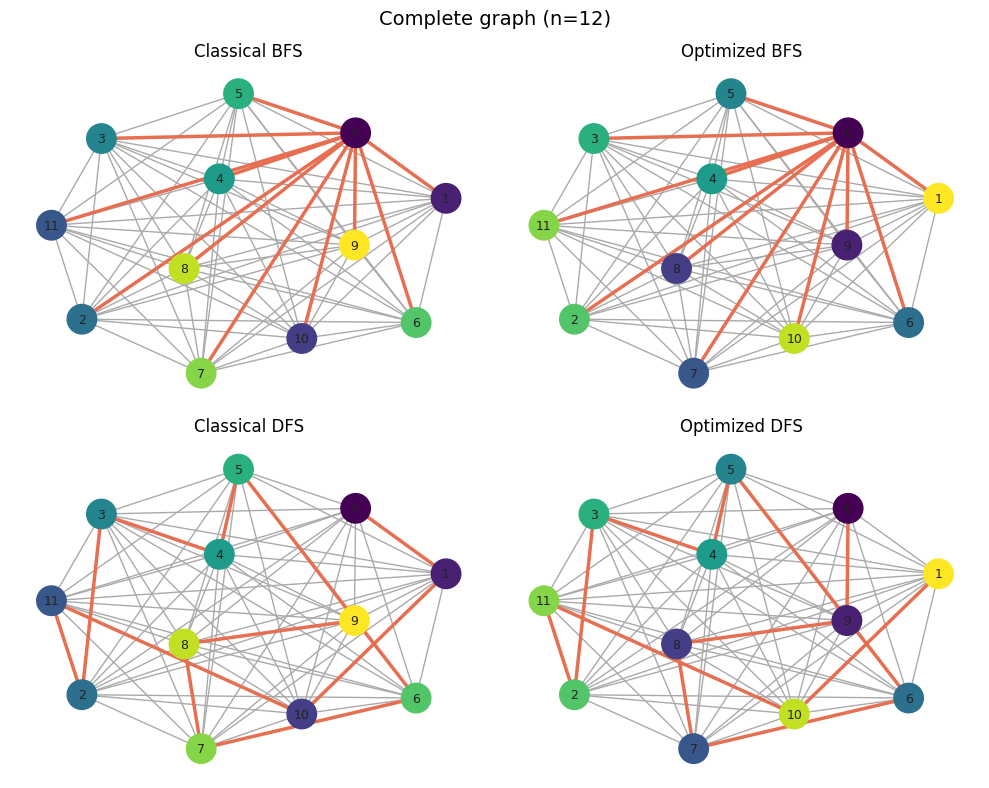

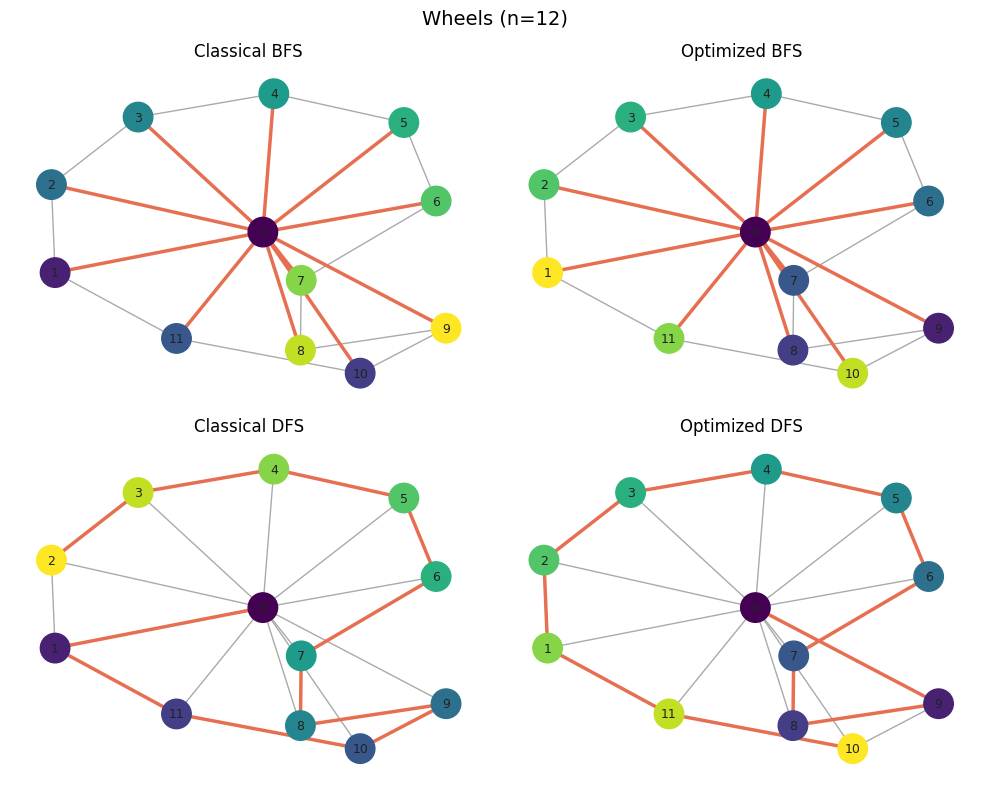

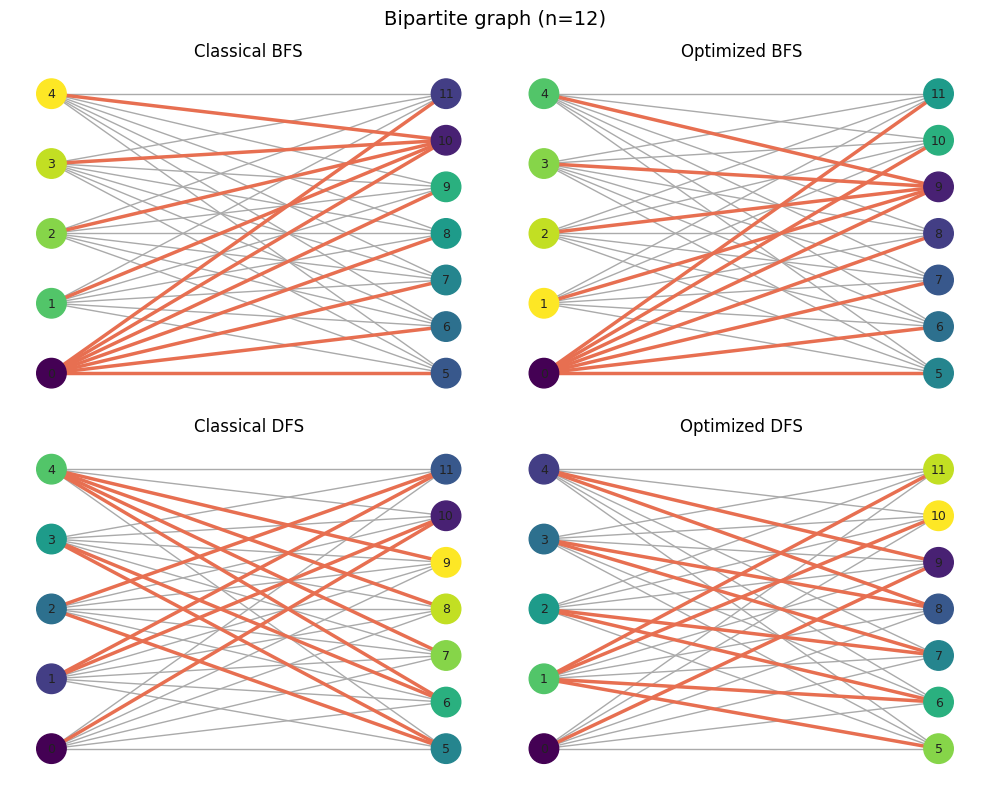

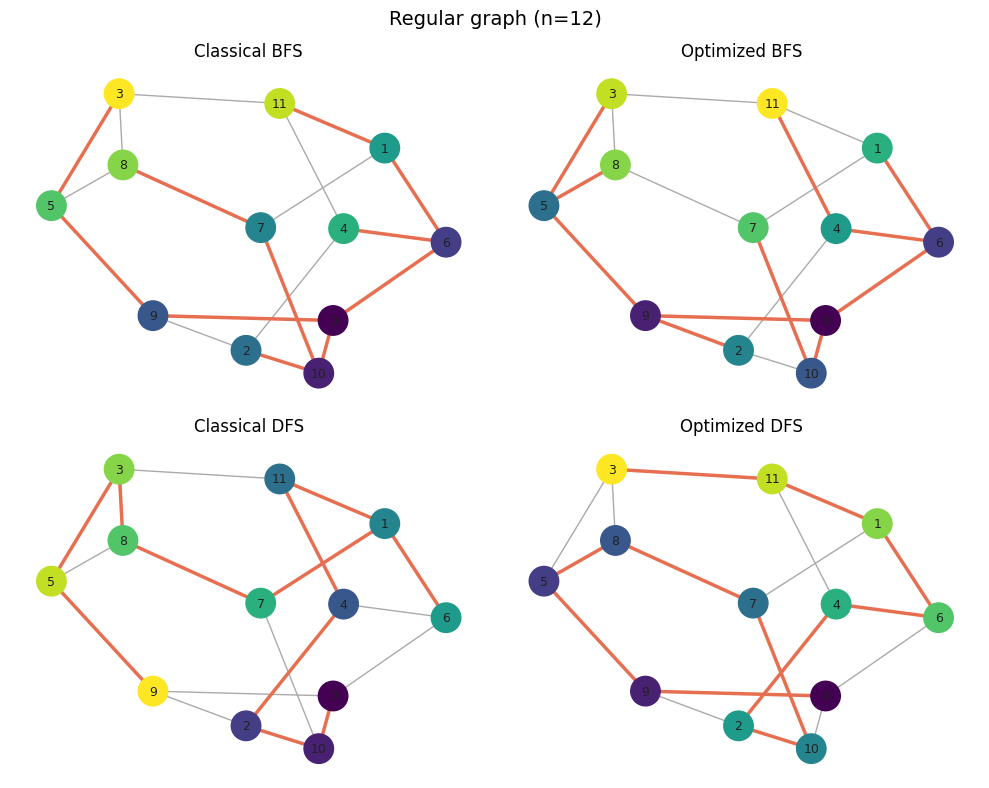

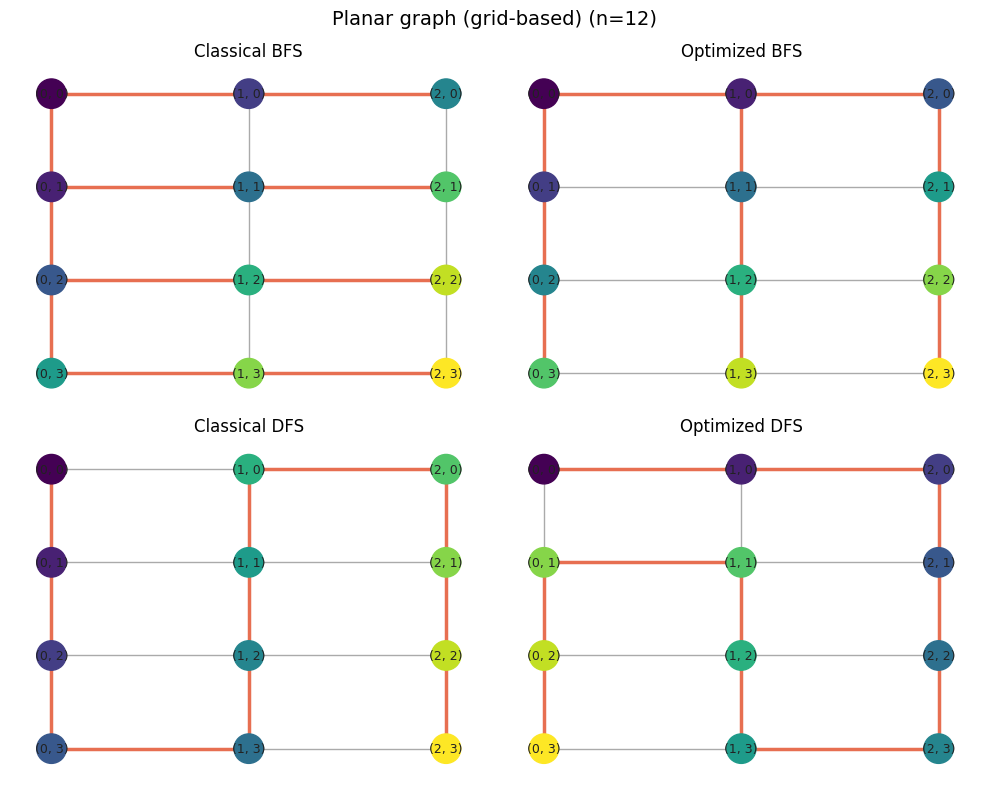

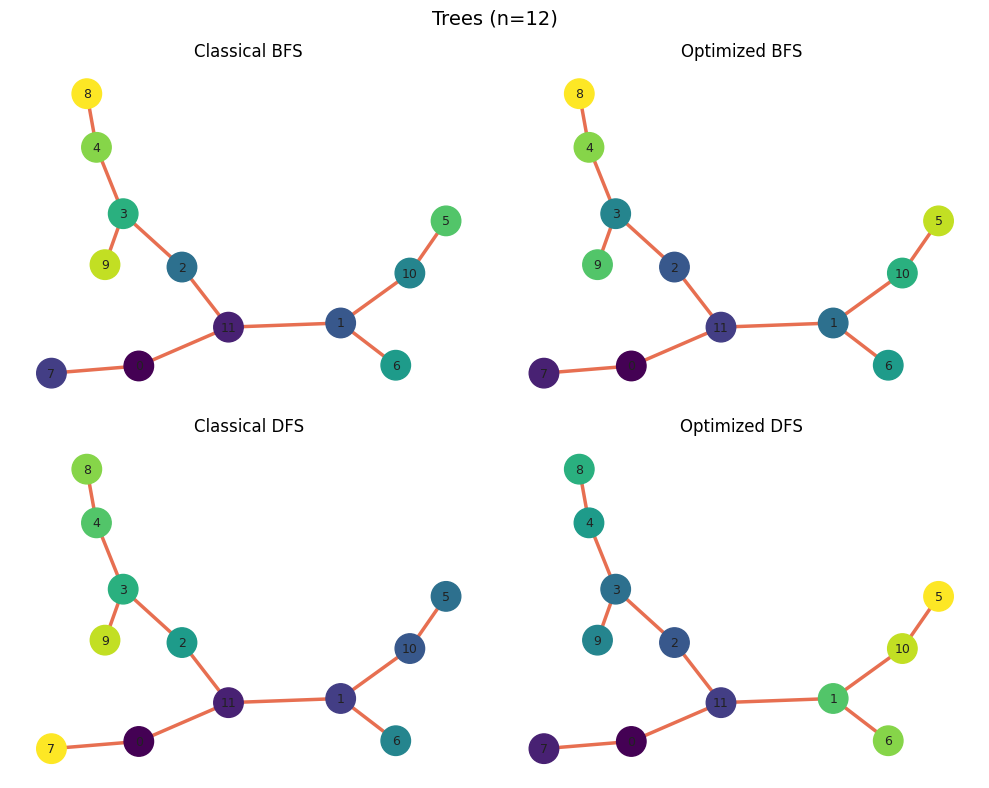

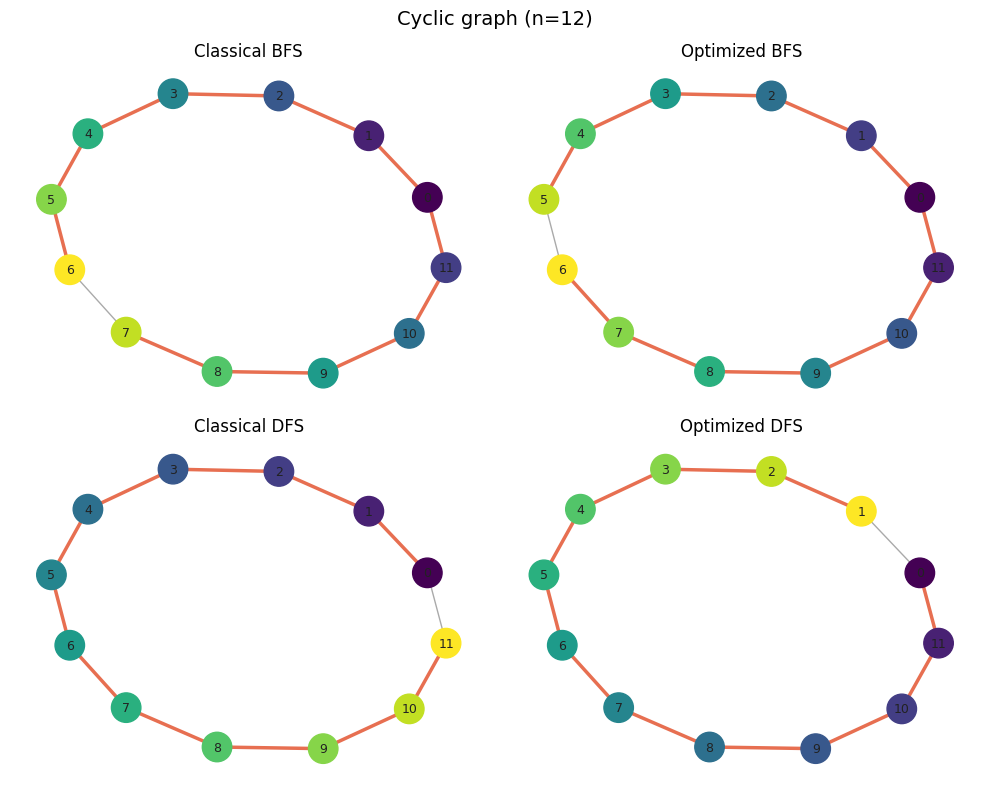

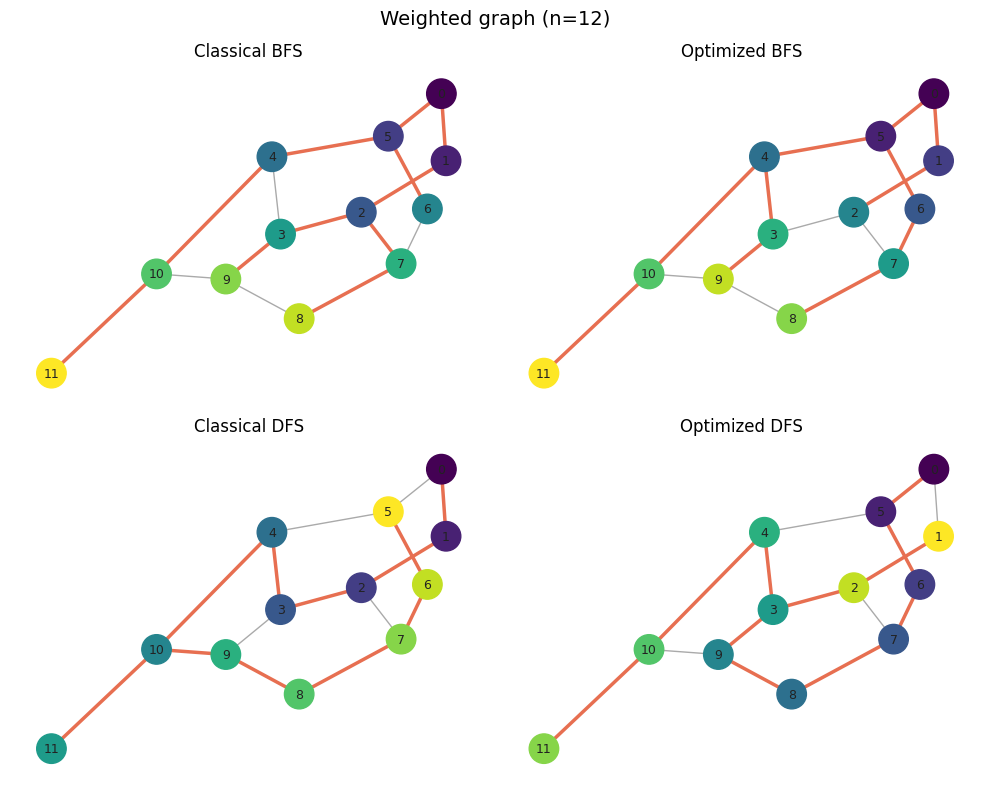

In [5]:
from collections import deque
import math
import random

import matplotlib.pyplot as plt
import networkx as nx

def _sorted_neighbors(G, u, reverse=False):
    return sorted(G.neighbors(u), key=str, reverse=reverse)

def _random_tree(n, seed):
    if n <= 1:
        return nx.empty_graph(n)
    rng = random.Random(seed)
    prufer = [rng.randrange(n) for _ in range(n - 2)]
    return nx.from_prufer_sequence(prufer)

def bfs_tree(G, start, reverse_neighbors=False):
    visited = {start}
    parent = {}
    order = []
    q = deque([start])
    while q:
        u = q.popleft()
        order.append(u)
        for v in _sorted_neighbors(G, u, reverse=reverse_neighbors):
            if v not in visited:
                visited.add(v)
                parent[v] = u
                q.append(v)
    edges = [(parent[v], v) for v in parent]
    return order, edges

def dfs_tree(G, start, reverse_neighbors=False):
    visited = set()
    parent = {}
    order = []
    stack = [start]
    while stack:
        u = stack.pop()
        if u in visited:
            continue
        visited.add(u)
        order.append(u)
        neighbors = _sorted_neighbors(G, u, reverse=reverse_neighbors)
        for v in reversed(neighbors):
            if v not in visited:
                parent[v] = u
                stack.append(v)
    edges = [(parent[v], v) for v in parent]
    return order, edges

def _multi_edge_styles(G):
    styles = []
    if not isinstance(G, (nx.MultiGraph, nx.MultiDiGraph)):
        return styles
    counts = {}
    for u, v, k in G.edges(keys=True):
        key = (u, v) if G.is_directed() else tuple(sorted([u, v], key=str))
        counts[key] = counts.get(key, 0) + 1
    for u, v, k in G.edges(keys=True):
        key = (u, v) if G.is_directed() else tuple(sorted([u, v], key=str))
        idx = counts[key]
        rad = 0.2 * (1 if idx % 2 == 0 else -1)
        counts[key] -= 1
        styles.append((u, v, k, rad))
    return styles

def _draw_graph(G, pos, ax, highlight_edges=None, title="", node_order=None):
    ax.set_title(title)
    ax.axis("off")
    base_color = "#c7c7c7"
    node_colors = []
    if node_order is None:
        node_order = list(G.nodes())
    order_index = {n: i for i, n in enumerate(node_order)}
    for n in G.nodes():
        if n in order_index:
            node_colors.append(plt.cm.viridis(order_index[n] / max(1, len(node_order) - 1)))
        else:
            node_colors.append(base_color)
    if isinstance(G, (nx.MultiGraph, nx.MultiDiGraph)):
        styles = _multi_edge_styles(G)
        for u, v, k, rad in styles:
            nx.draw_networkx_edges(
                G, pos, ax=ax, edgelist=[(u, v)],
                connectionstyle=f"arc3,rad={rad}",
                arrows=G.is_directed(), edge_color="#aaaaaa", width=1.0
            )
    else:
        nx.draw_networkx_edges(G, pos, ax=ax, arrows=G.is_directed(), edge_color="#aaaaaa", width=1.0)
    if highlight_edges:
        nx.draw_networkx_edges(
            G, pos, ax=ax, edgelist=highlight_edges,
            arrows=G.is_directed(), edge_color="#e76f51", width=2.5
        )
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=450)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="#222222")

def build_graph(graph_type, n=12):
    if graph_type == "Simple graph":
        G = nx.Graph()
        G.add_nodes_from(range(n))
        G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (1, 6), (2, 7), (3, 8), (4, 9), (5, 10), (6, 11)])
    elif graph_type == "Multigraph":
        G = nx.MultiGraph()
        G.add_nodes_from(range(n))
        G.add_edges_from([(0, 1), (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (2, 8), (3, 9), (4, 10), (5, 11)])
    elif graph_type == "Pseudograph":
        G = nx.MultiGraph()
        G.add_nodes_from(range(n))
        G.add_edges_from([(0, 0), (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (2, 6), (3, 7), (4, 8), (5, 9), (6, 10), (7, 11)])
    elif graph_type == "Directed graph":
        G = nx.DiGraph()
        G.add_nodes_from(range(n))
        G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), (2, 6), (6, 7), (7, 8), (8, 2), (4, 9), (9, 10), (10, 11)])
    elif graph_type == "Directed Multigraph":
        G = nx.MultiDiGraph()
        G.add_nodes_from(range(n))
        G.add_edges_from([(0, 1), (0, 1), (1, 2), (2, 3), (3, 4), (4, 2), (2, 5), (5, 6), (6, 7), (7, 5), (3, 8), (8, 9), (9, 10), (10, 11)])
    elif graph_type == "Complete graph":
        G = nx.complete_graph(n)
    elif graph_type == "Wheels":
        G = nx.wheel_graph(n)
    elif graph_type == "Bipartite graph":
        G = nx.complete_bipartite_graph(5, n - 5)
    elif graph_type == "Regular graph":
        G = nx.random_regular_graph(3, n, seed=RANDOM_SEED)
    elif graph_type == "Planar graph (grid-based)":
        G = nx.grid_2d_graph(3, 4)
    elif graph_type == "Trees":
        G = _random_tree(n, seed=RANDOM_SEED)
    elif graph_type == "Cyclic graph":
        G = nx.cycle_graph(n)
    elif graph_type == "Weighted graph":
        G = nx.Graph()
        G.add_nodes_from(range(n))
        edges = [(i, i + 1) for i in range(n - 1)]
        edges += [(0, 5), (2, 7), (3, 9), (4, 10)]
        G.add_edges_from(edges)
        for u, v in G.edges():
            G[u][v]["weight"] = (u + v) % 7 + 1
    else:
        G = nx.Graph()
        G.add_nodes_from(range(n))
        G.add_edges_from([(i, i + 1) for i in range(n - 1)])
    return G

def _layout_for_graph(graph_type, G):
    if graph_type == "Planar graph (grid-based)":
        return {n: (n[0], -n[1]) for n in G.nodes()}
    if graph_type == "Bipartite graph":
        return nx.bipartite_layout(G, nodes=range(5))
    return nx.spring_layout(G, seed=RANDOM_SEED)

def visualize_traversals(graph_type, n=12):
    G = build_graph(graph_type, n=n)
    pos = _layout_for_graph(graph_type, G)
    start = list(G.nodes())[0]
    bfs_order, bfs_edges = bfs_tree(G, start, reverse_neighbors=False)
    bfs_opt_order, bfs_opt_edges = bfs_tree(G, start, reverse_neighbors=True)
    dfs_order, dfs_edges = dfs_tree(G, start, reverse_neighbors=False)
    dfs_opt_order, dfs_opt_edges = dfs_tree(G, start, reverse_neighbors=True)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"{graph_type} (n={len(G.nodes())})", fontsize=14)
    _draw_graph(G, pos, axes[0, 0], bfs_edges, "Classical BFS", bfs_order)
    _draw_graph(G, pos, axes[0, 1], bfs_opt_edges, "Optimized BFS", bfs_opt_order)
    _draw_graph(G, pos, axes[1, 0], dfs_edges, "Classical DFS", dfs_order)
    _draw_graph(G, pos, axes[1, 1], dfs_opt_edges, "Optimized DFS", dfs_opt_order)
    plt.tight_layout()
    plt.show()

for graph_type in GRAPH_TYPES:
    visualize_traversals(graph_type, n=12)

In [ ]:
results = gac.run_all(GRAPH_TYPES, DENSITIES, VERTEX_SIZES, NUM_TRIALS, RANDOM_SEED)

for (graph_type, density), data in results.items():
    for n in sorted(list(data.keys())):
        avg_times = data[n]
        print(f"{graph_type} | {density} | n={int(n)} -> {avg_times}")

In [ ]:
def summarize_speedups(results):
    summary = {}
    for (graph_type, density), data in results.items():
        ratios = []
        for n, times in data.items():
            classical = times["classical_bfs"]
            optimized = times["optimized_bfs"]
            if classical > 0:
                ratios.append(classical / optimized if optimized > 0 else float("inf"))
        summary[(graph_type, density)] = sum(ratios) / len(ratios) if ratios else 0.0
    return summary

speedups = summarize_speedups(results)
for (graph_type, density), ratio in speedups.items():
    print(f"{graph_type} | {density} -> avg BFS speedup: {ratio:.2f}x")

Simple graph | sparse -> avg BFS speedup: 1.35x
Simple graph | dense -> avg BFS speedup: 0.74x
Multigraph | sparse -> avg BFS speedup: 1.43x
Multigraph | dense -> avg BFS speedup: 0.81x
Pseudograph | sparse -> avg BFS speedup: 1.57x
Pseudograph | dense -> avg BFS speedup: 0.86x
Directed graph | sparse -> avg BFS speedup: 1.35x
Directed graph | dense -> avg BFS speedup: 0.84x
Directed Multigraph | sparse -> avg BFS speedup: 1.34x
Directed Multigraph | dense -> avg BFS speedup: 0.88x
Complete graph | sparse -> avg BFS speedup: 1.60x
Complete graph | dense -> avg BFS speedup: 0.84x
Wheels | sparse -> avg BFS speedup: 3.80x
Wheels | dense -> avg BFS speedup: 0.94x
Bipartite graph | sparse -> avg BFS speedup: 1.64x
Bipartite graph | dense -> avg BFS speedup: 1.01x
Regular graph | sparse -> avg BFS speedup: 0.88x
Regular graph | dense -> avg BFS speedup: 0.91x
Planar graph (grid-based) | sparse -> avg BFS speedup: 1.19x
Planar graph (grid-based) | dense -> avg BFS speedup: 0.79x
Trees | spar

In [ ]:
def summarize_speedups_dfs(results):
    summary = {}
    for (graph_type, density), data in results.items():
        ratios = []
        for n, times in data.items():
            classical = times["classical_dfs"]
            optimized = times["optimized_dfs"]
            if classical > 0:
                ratios.append(classical / optimized if optimized > 0 else float("inf"))
        summary[(graph_type, density)] = sum(ratios) / len(ratios) if ratios else 0.0
    return summary

speedups_dfs = summarize_speedups_dfs(results)
for (graph_type, density), ratio in speedups_dfs.items():
    print(f"{graph_type} | {density} -> avg DFS speedup: {ratio:.2f}x")

Simple graph | sparse -> avg DFS speedup: 1.29x
Simple graph | dense -> avg DFS speedup: 1.14x
Multigraph | sparse -> avg DFS speedup: 1.32x
Multigraph | dense -> avg DFS speedup: 1.18x
Pseudograph | sparse -> avg DFS speedup: 1.24x
Pseudograph | dense -> avg DFS speedup: 1.04x
Directed graph | sparse -> avg DFS speedup: 1.35x
Directed graph | dense -> avg DFS speedup: 1.12x
Directed Multigraph | sparse -> avg DFS speedup: 1.47x
Directed Multigraph | dense -> avg DFS speedup: 1.11x
Complete graph | sparse -> avg DFS speedup: 1.30x
Complete graph | dense -> avg DFS speedup: 1.05x
Wheels | sparse -> avg DFS speedup: 1.10x
Wheels | dense -> avg DFS speedup: 1.03x
Bipartite graph | sparse -> avg DFS speedup: 1.31x
Bipartite graph | dense -> avg DFS speedup: 0.99x
Regular graph | sparse -> avg DFS speedup: 1.38x
Regular graph | dense -> avg DFS speedup: 1.19x
Planar graph (grid-based) | sparse -> avg DFS speedup: 1.34x
Planar graph (grid-based) | dense -> avg DFS speedup: 0.97x
Trees | spar

In [ ]:
import matplotlib.pyplot as plt

def plot_results(results, density):
    algo_labels = {
        "classical_dfs": "Classical DFS",
        "classical_bfs": "Classical BFS",
        "optimized_dfs": "Optimized DFS",
        "optimized_bfs": "Optimized BFS",
    }
    for graph_type in GRAPH_TYPES:
        key = (graph_type, density)
        if key not in results:
            continue
        data = results[key]
        sizes = sorted(list(data.keys()))
        plt.figure(figsize=(8, 5))
        for algo, label in algo_labels.items():
            ys = [data[n][algo] for n in sizes]
            plt.plot(sizes, ys, marker="o", label=label)
        plt.title(f"{graph_type} - {density}")
        plt.xlabel("Number of vertices (n)")
        plt.ylabel("Runtime (seconds)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

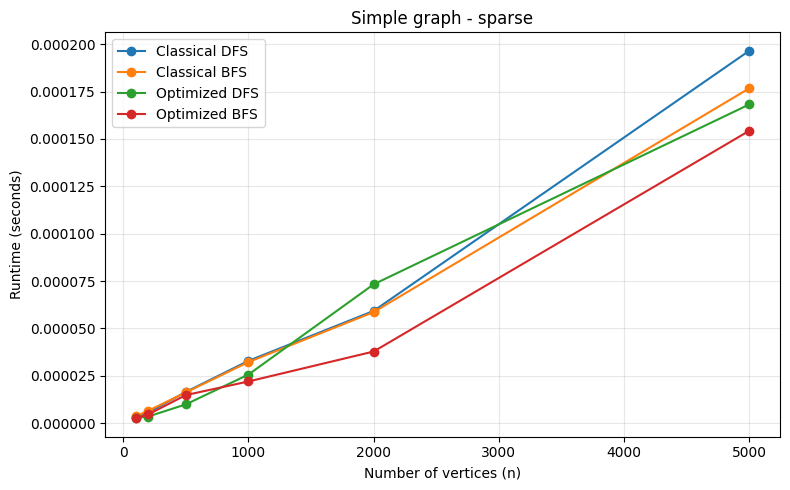

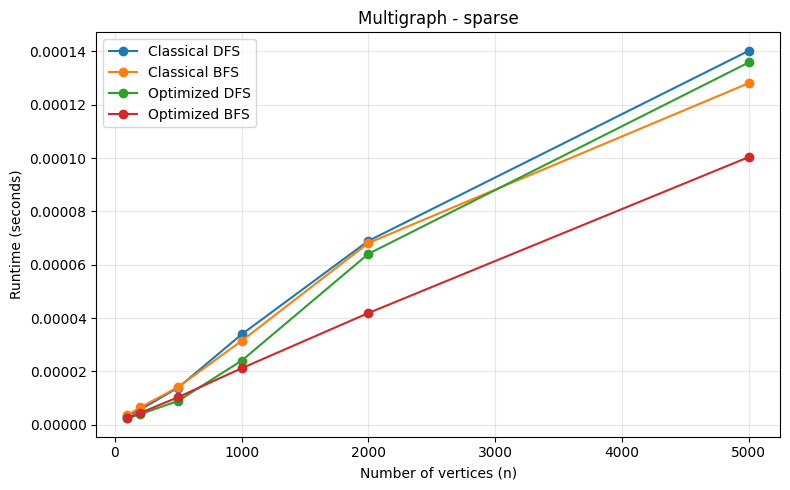

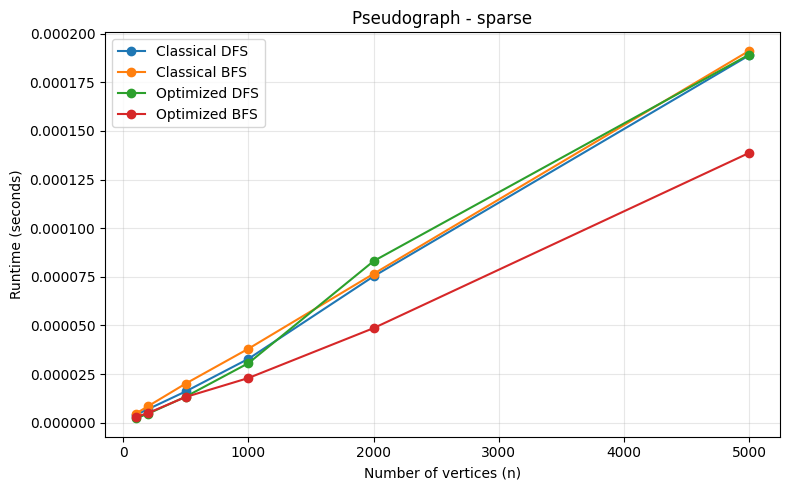

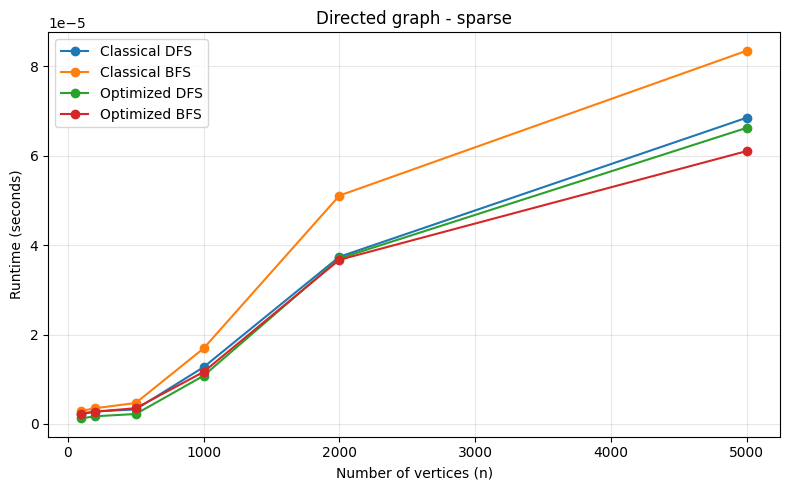

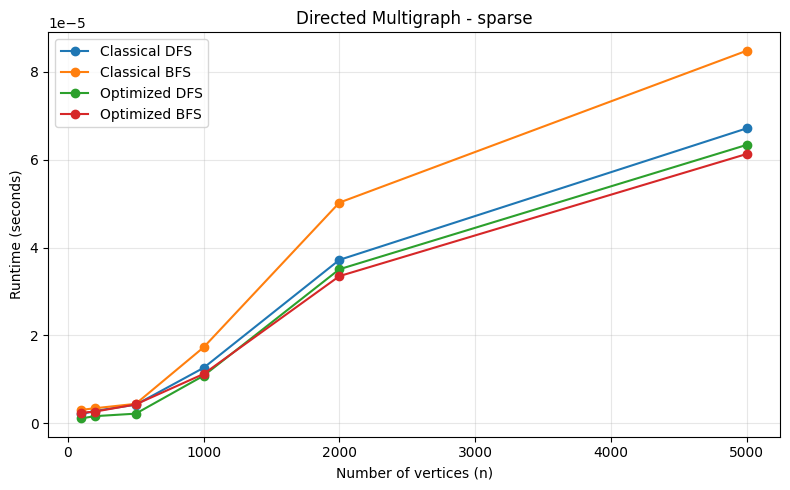

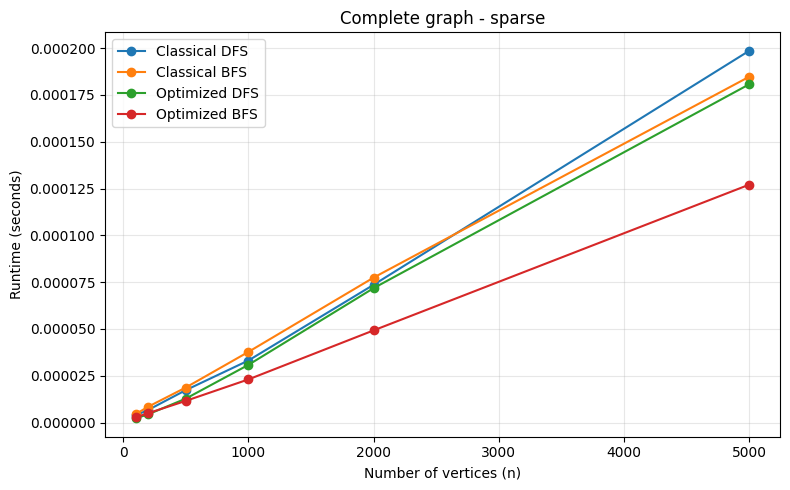

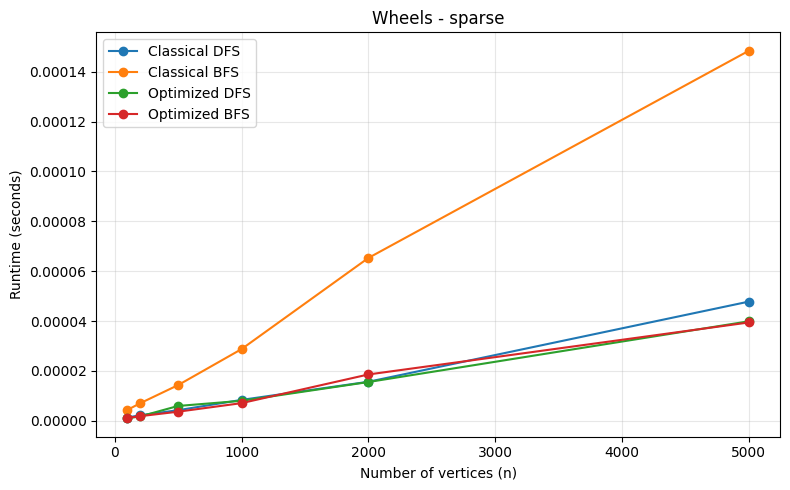

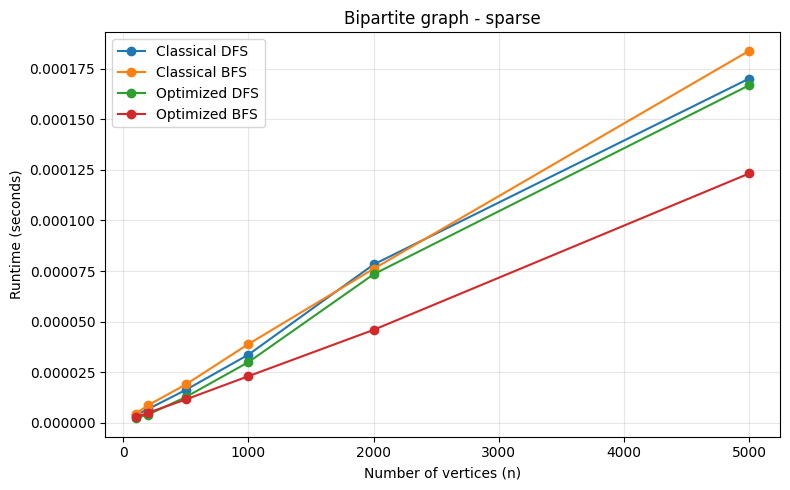

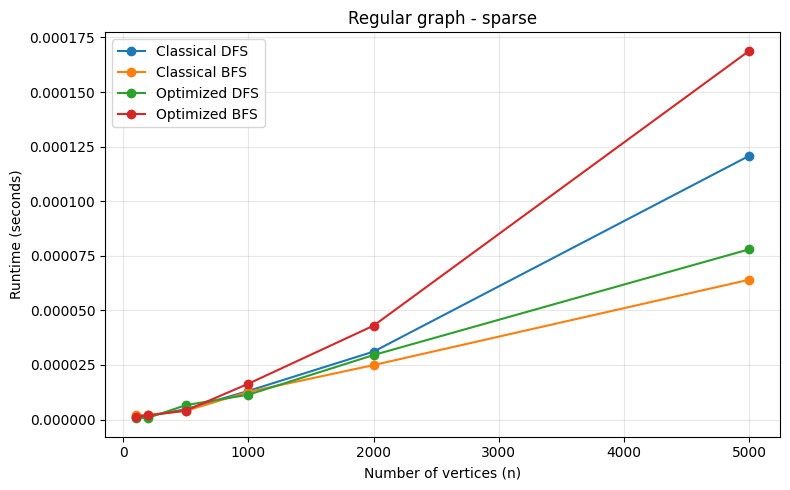

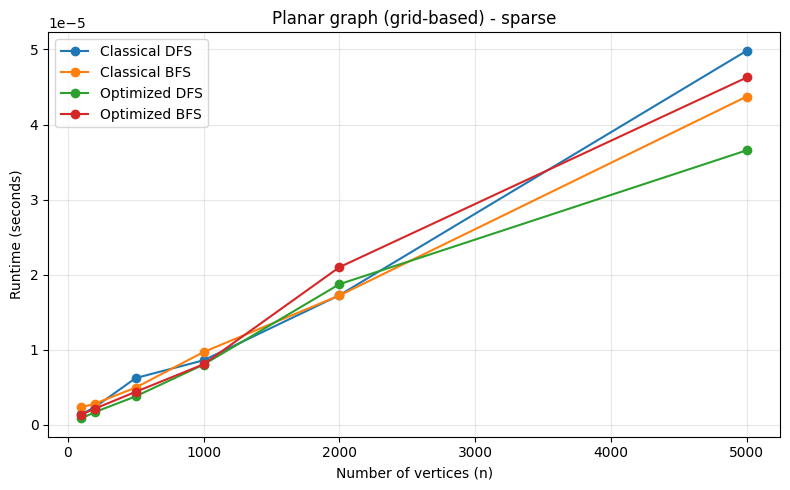

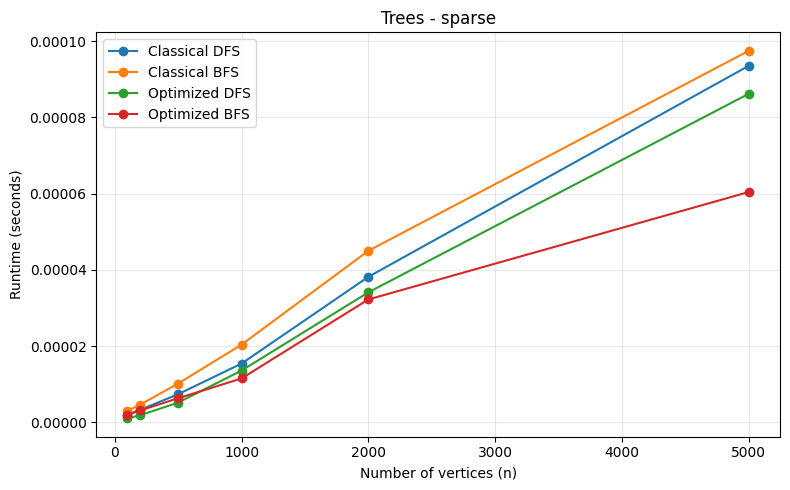

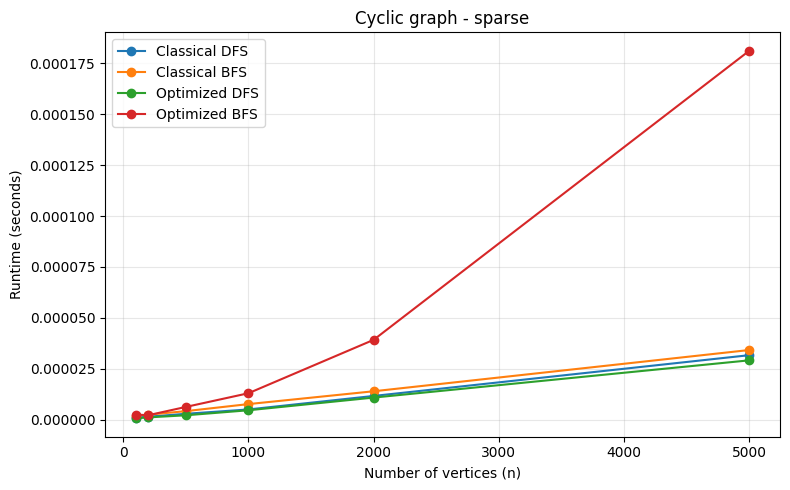

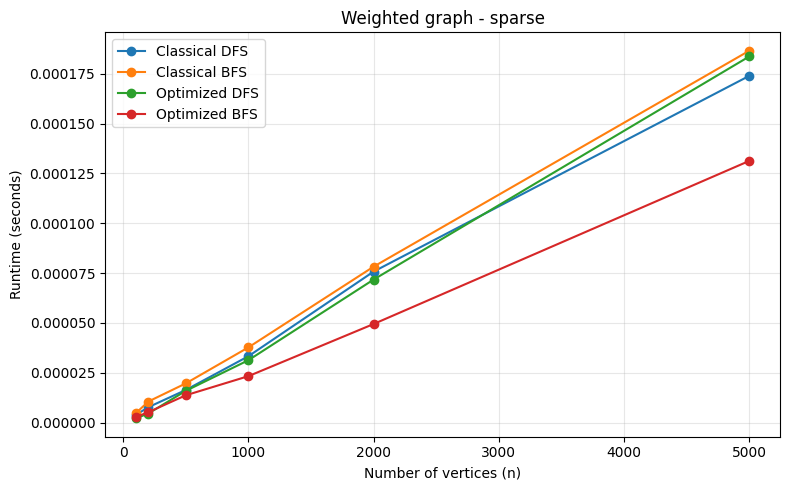

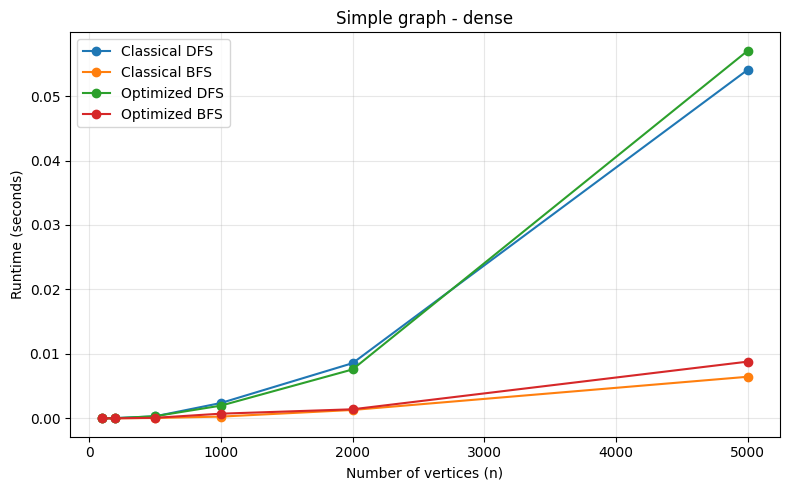

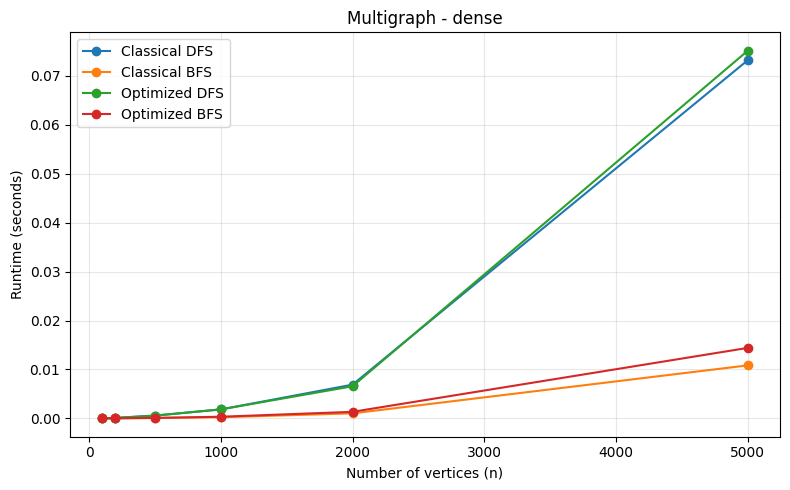

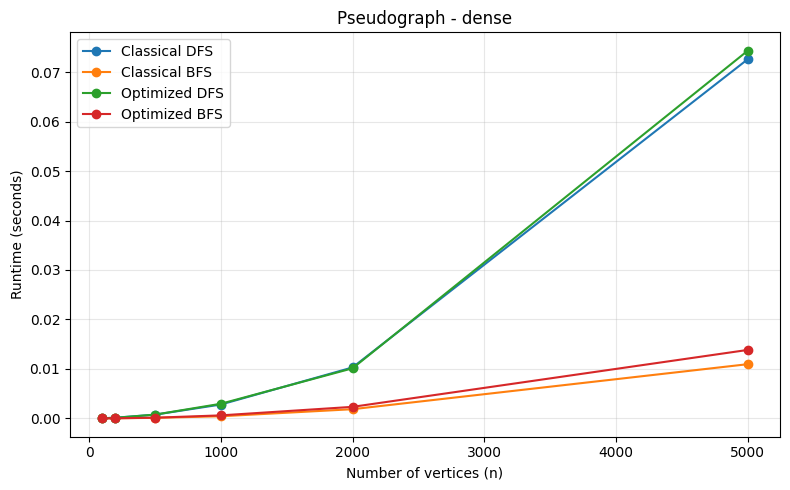

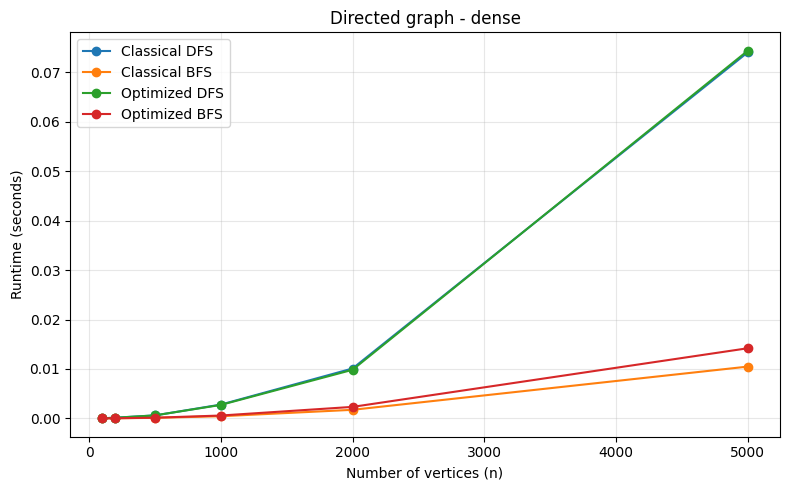

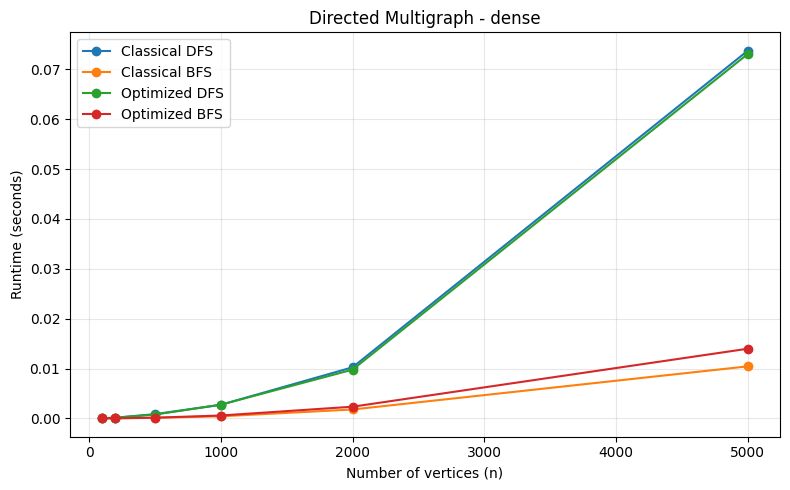

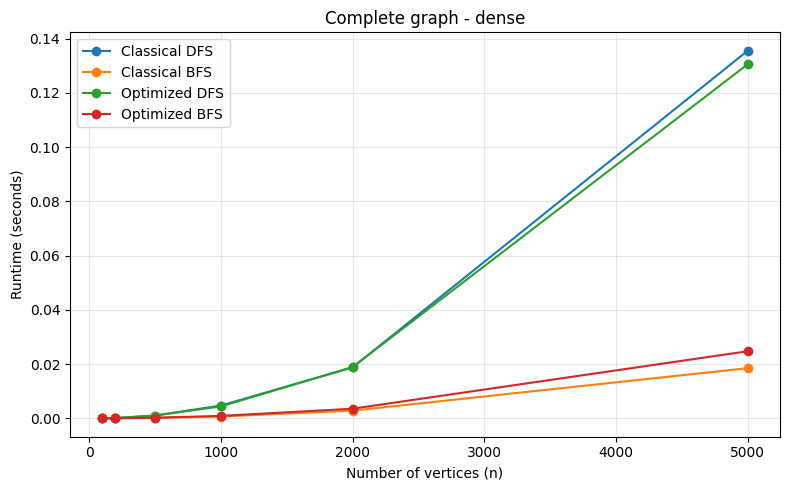

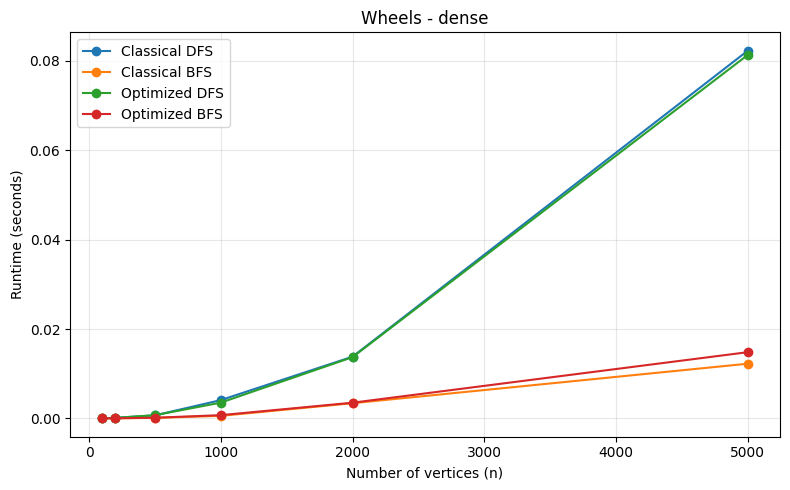

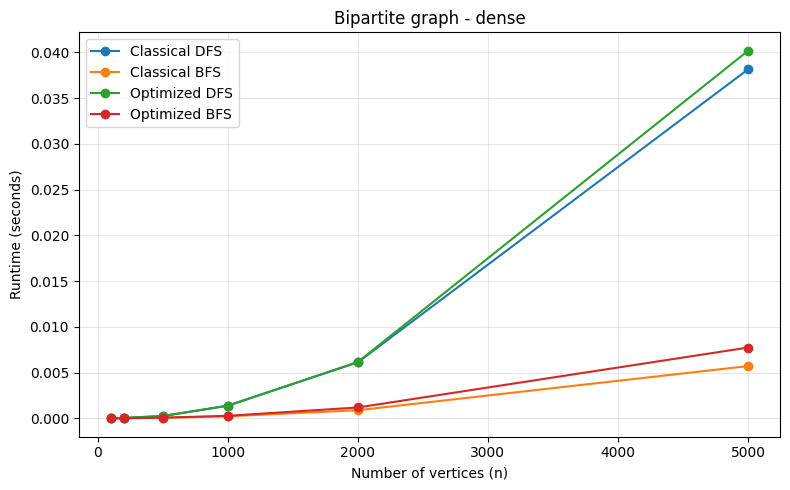

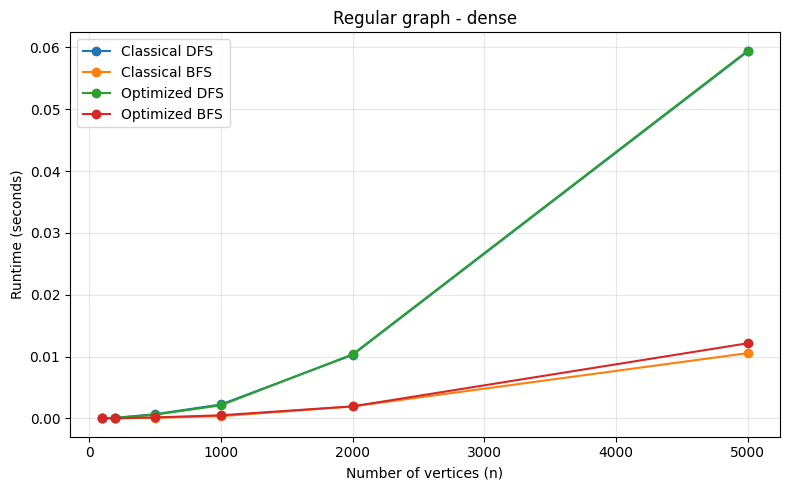

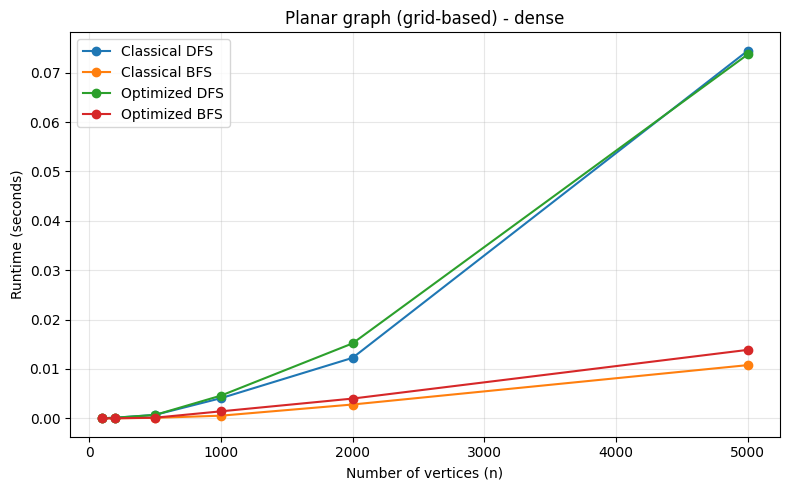

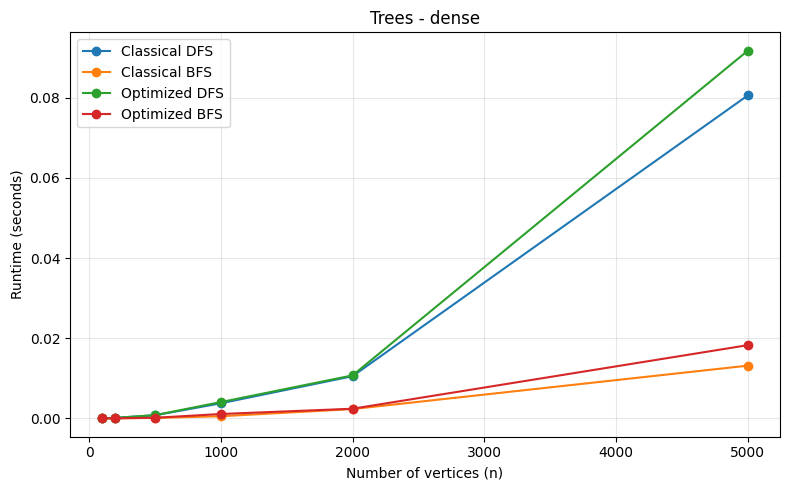

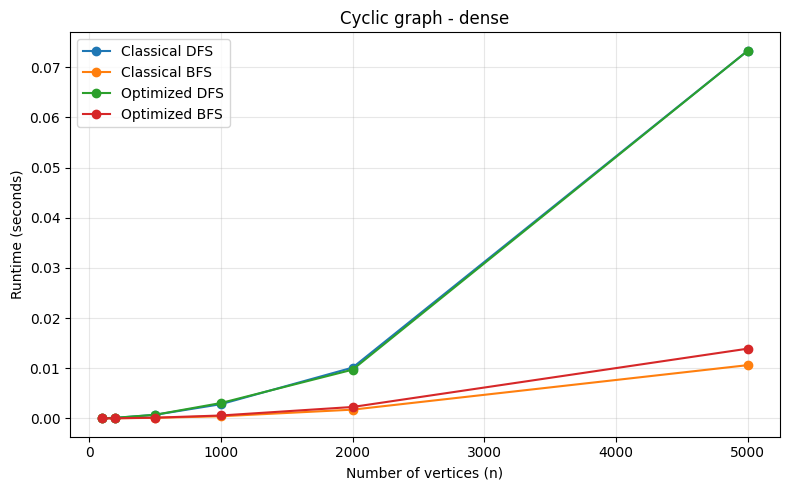

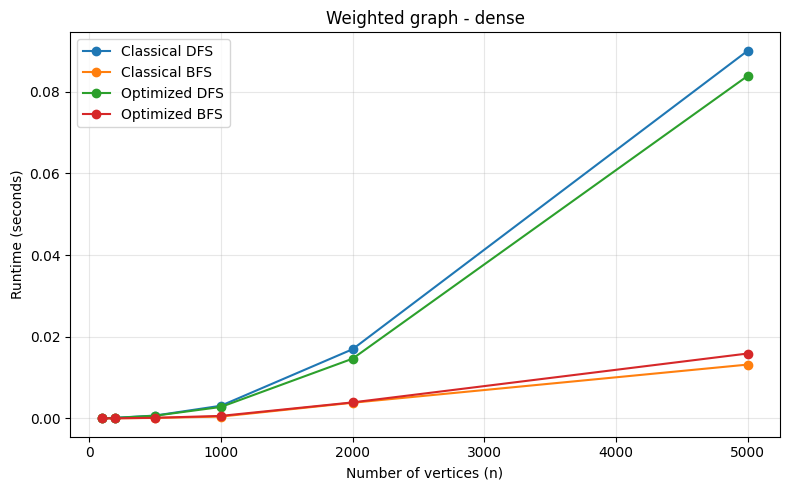

In [ ]:
plot_results(results, "sparse")
plot_results(results, "dense")

In [ ]:
results

{('Simple graph',
  'sparse'): {100: {'classical_dfs': 3.2e-06,
   'classical_bfs': 3.5666666666666663e-06,
   'optimized_dfs': 2.7e-06,
   'optimized_bfs': 2.5333333333333334e-06}, 200: {'classical_dfs': 5.633333333333333e-06,
   'classical_bfs': 6.533333333333334e-06,
   'optimized_dfs': 3.5e-06,
   'optimized_bfs': 4.6e-06}, 500: {'classical_dfs': 1.6466666666666666e-05,
   'classical_bfs': 1.62e-05,
   'optimized_dfs': 9.900000000000002e-06,
   'optimized_bfs': 1.4799999999999999e-05}, 1000: {'classical_dfs': 3.286666666666667e-05,
   'classical_bfs': 3.2233333333333335e-05,
   'optimized_dfs': 2.5633333333333334e-05,
   'optimized_bfs': 2.2000000000000003e-05}, 2000: {'classical_dfs': 5.9233333333333334e-05,
   'classical_bfs': 5.8599999999999995e-05,
   'optimized_dfs': 7.326666666666668e-05,
   'optimized_bfs': 3.78e-05}, 5000: {'classical_dfs': 0.00019656666666666666,
   'classical_bfs': 0.00017673333333333334,
   'optimized_dfs': 0.00016823333333333332,
   'optimized_bfs': 0.0